In [48]:
# 1. Import standard libraries & Setup
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pandas as pd
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
from functools import lru_cache
import copy
import warnings
import io
import sounddevice as sd
from IPython.display import Audio
from torchaudio.functional import resample

SAMPLE_RATE = 16000
NUM_SAMPLES = SAMPLE_RATE
TRAIN_SNR_RANGE = (-5.0, 20.0)
P_NOISE = 0.8
MAX_SHIFT_MS = 100
FREQ_MASK_PARAM = 7  # maximum sampled width: 6 Mel bands
TIME_MASK_PARAM = 11 # maximum sampled width: 10 frames

# Seed for reproducibility
SEED = 2026
torch.manual_seed(SEED)

# validate raw audio files
def read_pcm16(path):
    sr, pcm = wavfile.read(path)
    if sr != SAMPLE_RATE:
        raise ValueError(f"Expected {SAMPLE_RATE} Hz, got {sr}: {path}")
    if pcm.ndim != 1 or pcm.dtype != np.int16:
        raise ValueError(f"Expected mono PCM16, got shape={pcm.shape}, dtype={pcm.dtype}: {path}")
    if pcm.size == 0:
        raise ValueError(f"Empty audio file: {path}")
    return pcm


def read_audio(path):
    return read_pcm16(path).astype(np.float32) / 32768.0

# Check if GPU or CPU is used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [49]:
# 2. Parse splits from archive/
DATA_DIR = Path("archive")

if not DATA_DIR.exists():
    raise FileNotFoundError("The 'archive' directory was not found in the workspace.")

LABELS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
label_to_id = {word: i for i, word in enumerate(LABELS)}

# Read official split lists
with open(DATA_DIR / "validation_list.txt") as f:
    val_set = set(line.strip() for line in f if line.strip())

with open(DATA_DIR / "testing_list.txt") as f:
    test_set = set(line.strip() for line in f if line.strip())

raw_train_files, raw_train_labels = [], []
val_files,       val_labels       = [], []
test_files,      test_labels      = [], []

for word in LABELS:
    for p in sorted((DATA_DIR / word).glob("*.wav")):
        rel_path = f"{word}/{p.name}"
        lid = label_to_id[word]
        if rel_path in val_set:
            val_files.append(str(p))
            val_labels.append(lid)
        elif rel_path in test_set:
            test_files.append(str(p))
            test_labels.append(lid)
        else:
            raw_train_files.append(str(p))
            raw_train_labels.append(lid)

# verify speaker independence of the official splits.
def get_speakers(paths):
    return {Path(p).stem.split("_nohash_")[0] for p in paths}

train_speakers = get_speakers(raw_train_files)
val_speakers = get_speakers(val_files)
test_speakers = get_speakers(test_files)

assert train_speakers.isdisjoint(val_speakers)
assert train_speakers.isdisjoint(test_speakers)
assert val_speakers.isdisjoint(test_speakers)
assert val_set.isdisjoint(test_set)

for paths, labels in [(raw_train_files, raw_train_labels),
                      (val_files, val_labels), (test_files, test_labels)]:
    assert paths and len(paths) == len(labels)
    assert set(labels) == set(range(len(LABELS)))

print(f"Initial File Counts:")
print(f"  - Raw Train : {len(raw_train_files):,} recordings")
print(f"  - Val       : {len(val_files):,} recordings")
print(f"  - Test      : {len(test_files):,} recordings")


Initial File Counts:
  - Raw Train : 30,769 recordings
  - Val       : 3,703 recordings
  - Test      : 4,074 recordings


In [50]:
# 3. Audit & Filter severely clipped audio clips
print("Auditing training files for microphone clipping distortion...")
t0 = time.time()

clean_train_files = []
clean_train_labels = []
clipped_count = 0
raw_eda_records = []

for path_str, label in zip(raw_train_files, raw_train_labels):
    audio = read_pcm16(path_str)
    near_full_scale_ratio = float(np.mean(np.abs(audio.astype(np.int32)) >= 32440))
    dropped = near_full_scale_ratio > 0.005
    normalized = audio.astype(np.float64) / 32768.0
    mean_power = float(np.mean(normalized ** 2))
    raw_eda_records.append({
        "num_samples": len(audio),
        "duration_s": len(audio) / SAMPLE_RATE,
        "rms_dbfs": 10 * np.log10(mean_power) if mean_power > 0 else -np.inf,
        "peak": float(np.max(np.abs(normalized))),
        "dropped": dropped,
    })
    if dropped:
        clipped_count += 1
    else:
        clean_train_files.append(path_str)
        clean_train_labels.append(label)

raw_eda_df = pd.DataFrame(raw_eda_records)
t1 = time.time()
print(f"Audit completed in {t1 - t0:.2f} seconds:")
print(f"  - Dropped clipped files : {clipped_count} recordings (~{clipped_count/len(raw_train_files)*100:.1f}%)")
print(f"  - Clean training clips  : {len(clean_train_files):,} recordings")

train_files = clean_train_files
train_labels = clean_train_labels


Auditing training files for microphone clipping distortion...
Audit completed in 5.45 seconds:
  - Dropped clipped files : 350 recordings (~1.1%)
  - Clean training clips  : 30,419 recordings


In [51]:
#4: report the effect of clipping filtering for every label.
before = np.bincount(raw_train_labels, minlength=len(LABELS))
after = np.bincount(train_labels, minlength=len(LABELS))

cleaning_summary = pd.DataFrame({
    "before": before,
    "after": after,
    "dropped": before - after,
    "dropped_pct": (100.0 * (before - after) / before).round(2),
}, index=LABELS)
display(cleaning_summary)

,before,after,dropped,dropped_pct
yes,3228,3205,23,0.71
no,3130,3104,26,0.83
up,2948,2904,44,1.49
down,3134,3098,36,1.15
left,3037,2994,43,1.42
right,3019,2980,39,1.29
on,3086,3054,32,1.04
off,2970,2935,35,1.18
stop,3111,3071,40,1.29
go,3106,3074,32,1.03


In [52]:
#5: Noise split
TRAIN_NOISE_NAMES = ("doing_the_dishes", "exercise_bike", "pink_noise", "white_noise")
UNSEEN_NOISE_NAMES = ("running_tap", "dude_miaowing")
NOISE_DIR = DATA_DIR / "_background_noise_"

train_noise_bank, val_noise_bank, test_noise_bank = [], [], []
noise_records = []

def record_noise_segment(name, split, audio, start, end):
    segment = audio[start:end]
    assert len(segment) >= NUM_SAMPLES, f"Noise segment too short: {name}, {split}"
    noise_records.append({"noise": name, "split": split,
                          "duration_s": len(segment) / SAMPLE_RATE,
                          "fraction": len(segment) / len(audio)})
    return segment

# Seen sources: disjoint 80% / 10% / 10% segments for train / validation / seen test
for name in TRAIN_NOISE_NAMES:
    audio = read_audio(NOISE_DIR / f"{name}.wav")
    t_train, t_val = int(0.80 * len(audio)), int(0.90 * len(audio))
    train_noise_bank.append(record_noise_segment(name, "train", audio, 0, t_train))
    val_noise_bank.append(record_noise_segment(name, "validation", audio, t_train, t_val))
    test_noise_bank.append(record_noise_segment(name, "test_seen", audio, t_val, len(audio)))

# Unseen sources: complete recordings, final test only
for name in UNSEEN_NOISE_NAMES:
    audio = read_audio(NOISE_DIR / f"{name}.wav")
    test_noise_bank.append(record_noise_segment(name, "test_unseen", audio, 0, len(audio)))

test_noise_names = list(TRAIN_NOISE_NAMES + UNSEEN_NOISE_NAMES)
test_noise_groups = ["seen"] * len(TRAIN_NOISE_NAMES) + ["unseen"] * len(UNSEEN_NOISE_NAMES)

display(pd.DataFrame(noise_records).round(3))

C:\Users\Admin\AppData\Local\Temp\ipykernel_28384\3056414864.py:35: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, pcm = wavfile.read(path)


,noise,split,duration_s,fraction
0,doing_the_dishes,train,76.146,0.8
1,doing_the_dishes,validation,9.518,0.1
2,doing_the_dishes,test_seen,9.518,0.1
3,exercise_bike,train,49.003,0.8
4,exercise_bike,validation,6.125,0.1
5,exercise_bike,test_seen,6.125,0.1
6,pink_noise,train,48.000,0.8
7,pink_noise,validation,6.000,0.1
8,pink_noise,test_seen,6.000,0.1
9,white_noise,train,48.000,0.8


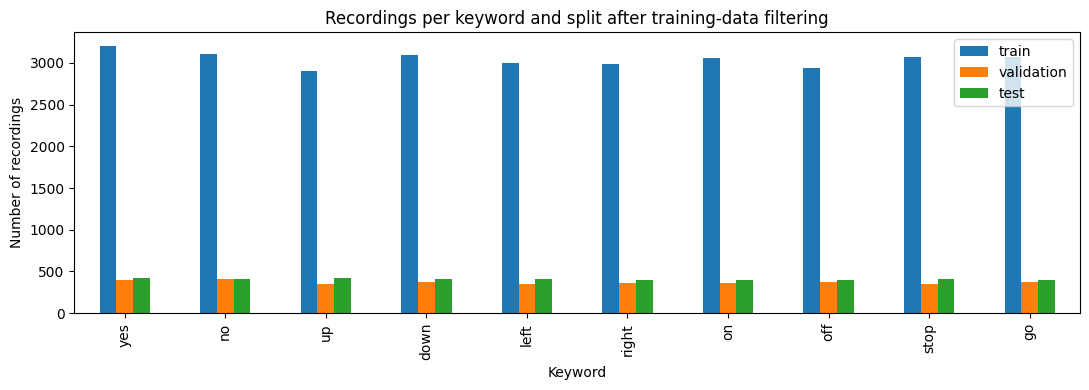

,duration_s,rms_dbfs,peak
count,30419.000,30419.000,30419.000
mean,0.982,-25.404,0.527
std,0.068,6.115,0.270
min,0.299,-47.133,0.006
25%,1.000,-29.424,0.293
50%,1.000,-24.400,0.523
75%,1.000,-20.923,0.762
max,1.000,-5.886,1.000


Shorter than one second: 2825


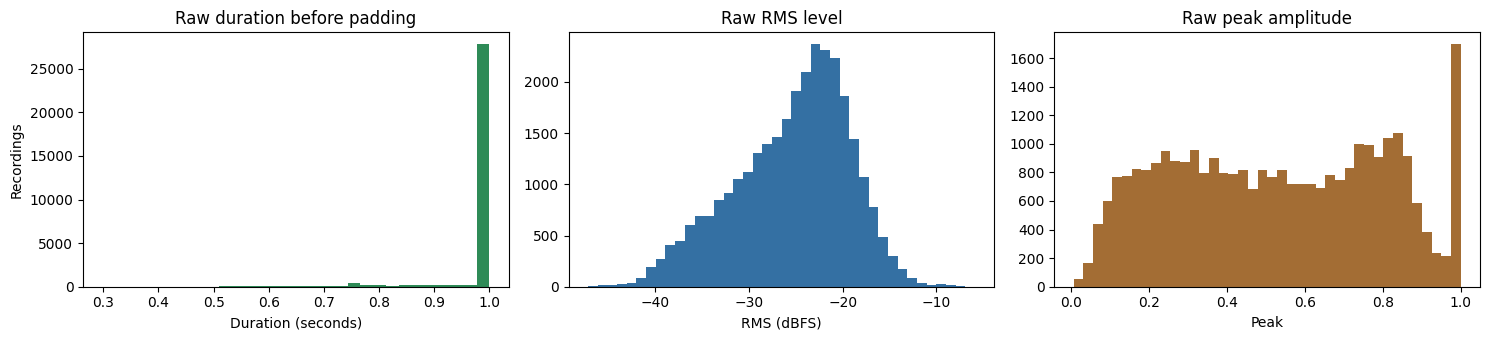

In [53]:
#6: Core EDA Visualizations
class_counts = pd.DataFrame({
    "train": np.bincount(train_labels, minlength=len(LABELS)),
    "validation": np.bincount(val_labels, minlength=len(LABELS)),
    "test": np.bincount(test_labels, minlength=len(LABELS)),
}, index=LABELS)

class_counts.plot.bar(figsize=(11, 4))
plt.title("Recordings per keyword and split after training-data filtering")
plt.xlabel("Keyword")
plt.ylabel("Number of recordings")
plt.tight_layout()
plt.show()

clean_raw_eda = raw_eda_df.loc[~raw_eda_df["dropped"]]
display(clean_raw_eda[["duration_s", "rms_dbfs", "peak"]].describe().round(3))
print("Shorter than one second:", int((clean_raw_eda["num_samples"] < NUM_SAMPLES).sum()))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(clean_raw_eda["duration_s"], bins=30, color="#2e8b57")
axes[0].set(title="Raw duration before padding", xlabel="Duration (seconds)", ylabel="Recordings")
finite_rms = clean_raw_eda.loc[np.isfinite(clean_raw_eda["rms_dbfs"]), "rms_dbfs"]
axes[1].hist(finite_rms, bins=40, color="#3470a3")
axes[1].set(title="Raw RMS level", xlabel="RMS (dBFS)")
axes[2].hist(clean_raw_eda["peak"], bins=40, color="#a36d34")
axes[2].set(title="Raw peak amplitude", xlabel="Peak")
plt.tight_layout()
plt.show()

In [54]:
#7: Log-Mel audio front-end
class AudioFrontEnd(nn.Module):
    def __init__(self, sample_rate=SAMPLE_RATE, n_fft=512, win_length=None, hop_length=None, n_mels=40):
        super().__init__()
        win_length = round(0.030 * sample_rate) if win_length is None else win_length
        hop_length = round(0.010 * sample_rate) if hop_length is None else hop_length
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.mel = T.MelSpectrogram(
            sample_rate=sample_rate, n_fft=n_fft, win_length=win_length,
            hop_length=hop_length, n_mels=n_mels,
            mel_scale="htk", power=2.0, center=True, pad_mode="reflect",
        )
        self.to_db = T.AmplitudeToDB(top_db=80.0)

    def forward(self, wav):
        spec = self.to_db(self.mel(wav).unsqueeze(1)).squeeze(1)
        mean = spec.mean(dim=(-2, -1), keepdim=True)
        std = spec.std(dim=(-2, -1), keepdim=True)
        spec = (spec - mean) / (std + 1e-6)
        return spec.unsqueeze(1)

In [55]:
#8: SpecAugment layer
class SpecAugment(nn.Module):
    def __init__(self, freq_mask_param=FREQ_MASK_PARAM, time_mask_param=TIME_MASK_PARAM,
                 freq_masks=1, time_masks=1):
        super().__init__()
        self.freq_mask = T.FrequencyMasking(freq_mask_param=freq_mask_param, iid_masks=True)
        self.time_mask = T.TimeMasking(time_mask_param=time_mask_param, iid_masks=True)
        self.freq_masks_num = freq_masks
        self.time_masks_num = time_masks

    def forward(self, spec: torch.Tensor) -> torch.Tensor:
        if not self.training:
            return spec
        for _ in range(self.freq_masks_num):
            spec = self.freq_mask(spec)
        for _ in range(self.time_masks_num):
            spec = self.time_mask(spec)
        return spec

In [56]:
#9: Audio processing and the training / noisy-evaluation datasets
@lru_cache(maxsize=None)

def load_audio(path):
    audio = read_audio(path)
    if len(audio) > NUM_SAMPLES:
        raise ValueError(f"Audio longer than {NUM_SAMPLES / SAMPLE_RATE:.2f}s: {path}")
    missing = NUM_SAMPLES - len(audio)
    left = missing // 2
    return np.pad(audio, (left, missing - left))

def power(audio):
    return float(np.mean(audio.astype(np.float64) ** 2))

def mix_at_snr(speech, noise, snr_db):
    if speech.shape != noise.shape:
        raise ValueError("Speech and noise must have the same shape")
    p_speech, p_noise = power(speech), power(noise)
    if not np.isfinite([p_speech, p_noise, snr_db]).all():
        raise ValueError("Non-finite power or SNR")
    if p_speech <= 1e-12 or p_noise <= 1e-12:
        raise ValueError("Speech or noise has insufficient energy")
    scale = np.sqrt(p_speech / (p_noise * 10 ** (snr_db / 10)))
    return (speech + scale * noise).astype(np.float32)

def limit_peak(audio):
    peak = float(np.max(np.abs(audio)))
    return (audio / max(1.0, peak)).astype(np.float32)

def mix_noise_at_snr(speech, noise, snr_db):
    return limit_peak(mix_at_snr(speech, noise, snr_db))

def sample_noise_clip(noise_bank, rng):
    if not noise_bank:
        raise ValueError("Noise bank is empty")
    for _ in range(10):
        track = noise_bank[int(rng.integers(len(noise_bank)))]
        if len(track) < NUM_SAMPLES:
            raise ValueError("Noise segment is shorter than one speech clip")
        start = int(rng.integers(0, len(track) - NUM_SAMPLES + 1))
        clip = track[start:start + NUM_SAMPLES]
        if np.isfinite(clip).all() and power(clip) > 1e-12:
            return clip
    raise ValueError("Could not find a usable noise clip after 10 attempts")

def shift_audio(audio, rng, max_shift_ms=MAX_SHIFT_MS):
    max_shift = round(max_shift_ms / 1000 * SAMPLE_RATE)
    if not 0 <= max_shift < len(audio):
        raise ValueError("Time shift must be nonnegative and shorter than the waveform")
    s = int(rng.integers(-max_shift, max_shift + 1))
    out = np.zeros_like(audio)
    if s > 0:
        out[s:] = audio[:-s]
    elif s < 0:
        out[:s] = audio[-s:]
    else:
        out[:] = audio
    return out


class KWSDataset(Dataset):
    def __init__(self, file_paths, labels, noise_bank=None, is_train=False,
                 p_noise=P_NOISE, seed=SEED, snr_range=TRAIN_SNR_RANGE):
        if len(file_paths) != len(labels):
            raise ValueError("File and label counts differ")
        if not 0 <= p_noise <= 1:
            raise ValueError("p_noise must be between 0 and 1")
        if is_train and p_noise > 0 and not noise_bank:
            raise ValueError("Training noise augmentation requires a noise bank")
        self.file_paths, self.labels = file_paths, labels
        self.noise_bank, self.is_train = noise_bank, is_train
        self.p_noise, self.snr_range = p_noise, snr_range
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio = load_audio(self.file_paths[idx])
        if self.is_train:
            audio = shift_audio(audio, self.rng)
            if self.rng.random() < self.p_noise:
                noise_slice = sample_noise_clip(self.noise_bank, self.rng)
                snr = float(self.rng.uniform(*self.snr_range))
                audio = mix_noise_at_snr(audio, noise_slice, snr)
        return torch.from_numpy(audio), int(self.labels[idx])


EVAL_SNRS = [20, 10, 5, 0, -5]


class NoisyEvalDataset(Dataset):
    def __init__(self, file_paths, labels, noise_bank, noise_idx, snr_db, seed=SEED):
        if len(file_paths) != len(labels) or not noise_bank:
            raise ValueError("Invalid evaluation files, labels or noise bank")
        if noise_idx is not None and not 0 <= noise_idx < len(noise_bank):
            raise ValueError("noise_idx is out of range")
        self.file_paths, self.labels = file_paths, labels
        self.noise_bank, self.noise_idx = noise_bank, noise_idx
        self.snr_db, self.seed = snr_db, seed

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio = load_audio(self.file_paths[idx])
        rng = np.random.default_rng([self.seed, idx])
        k = self.noise_idx if self.noise_idx is not None else int(rng.integers(len(self.noise_bank)))
        noise_slice = sample_noise_clip([self.noise_bank[k]], rng)
        snr = self.snr_db if self.snr_db is not None else float(rng.choice(EVAL_SNRS))
        audio = mix_noise_at_snr(audio, noise_slice, snr)
        return torch.from_numpy(audio), int(self.labels[idx])


In [57]:
#10: DataLoaders
BATCH_SIZE = 100
pin = (device.type == "cuda")

def make_train_loader(seed=SEED):
    torch.manual_seed(seed)
    dataset = KWSDataset(train_files, train_labels, noise_bank=train_noise_bank,
                         is_train=True, seed=seed)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                      pin_memory=pin, num_workers=0,
                      generator=torch.Generator().manual_seed(seed))

train_loader = make_train_loader()
val_dataset = KWSDataset(val_files, val_labels, is_train=False)
test_dataset = KWSDataset(test_files, test_labels, is_train=False)
val_noisy_dataset = NoisyEvalDataset(val_files, val_labels, val_noise_bank,
                                    noise_idx=None, snr_db=None)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, pin_memory=pin, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, pin_memory=pin, num_workers=0)
val_noisy_loader = DataLoader(val_noisy_dataset, batch_size=256, shuffle=False,
                              pin_memory=pin, num_workers=0)

def make_test_loader(noise_idx, snr_db):
    ds = NoisyEvalDataset(test_files, test_labels, test_noise_bank,
                         noise_idx=noise_idx, snr_db=snr_db)
    return DataLoader(ds, batch_size=256, shuffle=False, pin_memory=pin, num_workers=0)

# Iterate over all test noise conditions
def iter_test_loaders():
    for noise_idx, (noise_name, group) in enumerate(zip(test_noise_names, test_noise_groups)):
        for snr_db in EVAL_SNRS:
            yield group, noise_name, snr_db, make_test_loader(noise_idx, snr_db)

print(f"DataLoaders ready! Batch size = {BATCH_SIZE}")
print(f"Train batches per epoch: {len(train_loader)}")

DataLoaders ready! Batch size = 100
Train batches per epoch: 305


[PASS] 38,196 clips load and are non-silent
[PASS] SNR: 100 real mixes (1 peak-limited), plus edge cases
[PASS] Seen-noise validation datasets are deterministic; unseen noise reserved for final test
Waveform batch: (100, 16000) | Spectrogram batch: (100, 1, 40, 101)
[PASS] Batch, features, labels and SpecAugment.eval() verified


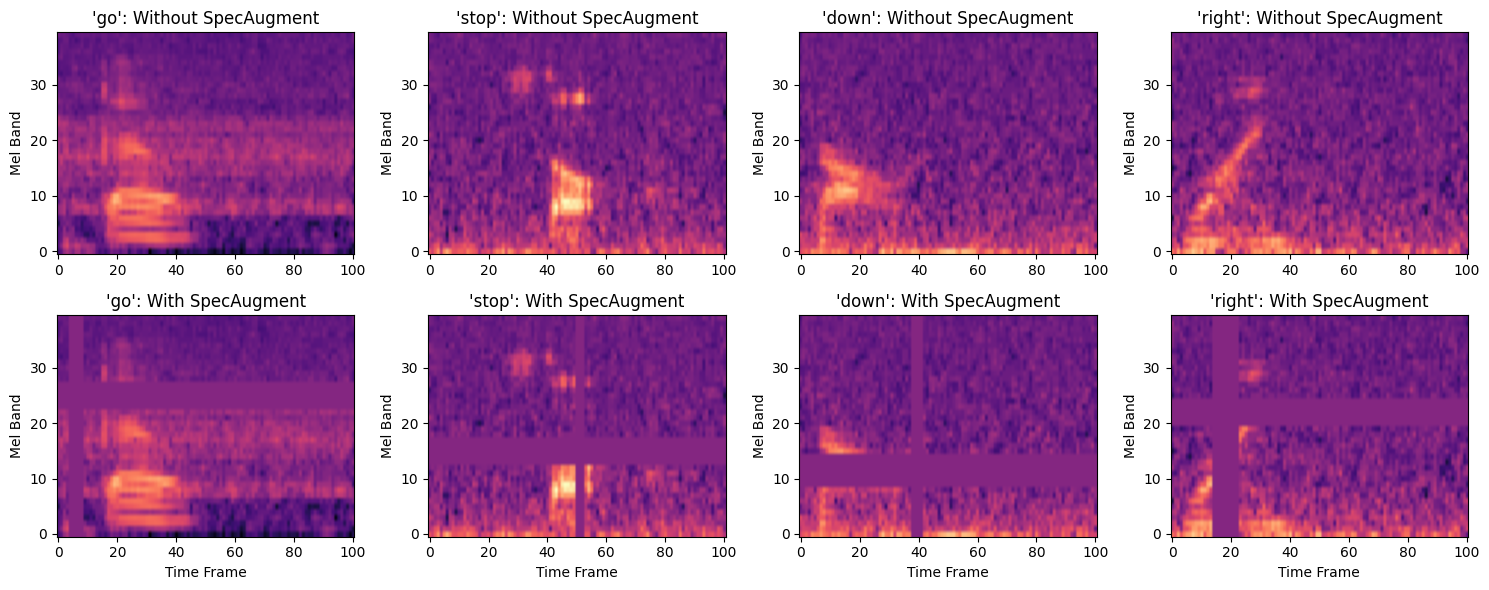

In [58]:
#11: Sanity check & Visualization

# Every clip loads as a one-second PCM16 waveform and is not silent
for split_name, files in [("train", train_files), ("validation", val_files), ("test", test_files)]:
    silent = [p for p in files if power(load_audio(p)) <= 1e-12]
    assert not silent, f"{split_name}: silent clips {silent[:5]}"
print(f"[PASS] {len(train_files) + len(val_files) + len(test_files):,} clips load and are non-silent")

# Mixing reaches the requested SNR before and after common-gain peak limiting
def verify_snr(speech, noise, target_snr):
    raw_mix = mix_at_snr(speech, noise, target_snr)
    measured_raw = 10 * np.log10(power(speech) / power(raw_mix - speech))
    gain = 1.0 / max(1.0, float(np.max(np.abs(raw_mix))))
    mixed = mix_noise_at_snr(speech, noise, target_snr)
    scaled_speech = gain * speech
    measured_limited = 10 * np.log10(power(scaled_speech) / power(mixed - scaled_speech))
    assert np.isclose(measured_raw, target_snr, atol=1e-3), (target_snr, measured_raw)
    assert np.isclose(measured_limited, target_snr, atol=1e-3), (target_snr, measured_limited)
    assert mixed.shape == (NUM_SAMPLES,) and np.isfinite(mixed).all()
    assert np.max(np.abs(mixed)) <= 1.0
    return gain < 1.0

# Validation speech/noise only, keeping test noise untouched until final evaluation
snr_rng = np.random.default_rng(SEED)
snr_checks = limited_checks = 0
for speech_idx in np.linspace(0, len(val_files)-1, min(5, len(val_files)), dtype=int):
    speech = load_audio(val_files[speech_idx])
    for track in val_noise_bank:
        noise = sample_noise_clip([track], snr_rng)
        for snr in EVAL_SNRS:
            limited_checks += int(verify_snr(speech, noise, snr))
            snr_checks += 1

# Edge cases: forced peak limiting and very low-power noise
synthetic_speech = np.full(NUM_SAMPLES, 0.8, dtype=np.float32)
synthetic_noise = np.where(np.arange(NUM_SAMPLES) % 2 == 0, 0.8, -0.8).astype(np.float32)
assert verify_snr(synthetic_speech, synthetic_noise, 0.0)
verify_snr(synthetic_speech * 0.0125, synthetic_noise * 0.000125, -5.0)
print(f"[PASS] SNR: {snr_checks} real mixes ({limited_checks} peak-limited), plus edge cases")

# Noisy validation samples are identical on every read
validation_eval_datasets = [val_noisy_dataset] + [
    NoisyEvalDataset(val_files, val_labels, val_noise_bank, noise_idx=k, snr_db=0.0)
    for k in range(len(val_noise_bank))
]
for ds in validation_eval_datasets:
    for idx in range(min(32, len(ds))):
        a, ya = ds[idx]
        b, yb = ds[idx]
        assert torch.equal(a, b) and ya == yb
print("[PASS] Seen-noise validation datasets are deterministic; unseen noise reserved for final test")

front_end = AudioFrontEnd().to(device)
spec_aug = SpecAugment().to(device)
# A dedicated sanity loader does not consume the training Dataset's RNG
sanity_loader = make_train_loader(seed=SEED + 1)
wav_batch, label_batch = next(iter(sanity_loader))
wav_batch, label_batch = wav_batch.to(device), label_batch.to(device)
actual_batch = len(label_batch)
assert wav_batch.shape == (actual_batch, NUM_SAMPLES)
assert wav_batch.dtype == torch.float32 and torch.isfinite(wav_batch).all()
assert label_batch.dtype == torch.long
assert 0 <= label_batch.min().item() and label_batch.max().item() < len(LABELS)

front_end.eval()
spec_aug.eval()
with torch.inference_mode():
    spec_without_mask = front_end(wav_batch)
    assert torch.equal(spec_aug(spec_without_mask), spec_without_mask)
spec_aug.train()
with torch.inference_mode():
    spec_augmented = spec_aug(spec_without_mask)
# Centered STFT: frame count depends only on NUM_SAMPLES and hop length
expected_shape = (actual_batch, 1, front_end.n_mels, 1 + NUM_SAMPLES // front_end.hop_length)
assert spec_augmented.shape == expected_shape
assert torch.isfinite(spec_augmented).all()
print(f"Waveform batch: {tuple(wav_batch.shape)} | Spectrogram batch: {tuple(spec_augmented.shape)}")
print("[PASS] Batch, features, labels and SpecAugment.eval() verified")

# SpecAugment preview for the ablation (main experiments train without masking)
N_PLOTS = min(4, actual_batch)
fig, axes = plt.subplots(2, N_PLOTS, figsize=(15, 6), squeeze=False)
vmin = min(spec_without_mask[:N_PLOTS].min().item(), spec_augmented[:N_PLOTS].min().item())
vmax = max(spec_without_mask[:N_PLOTS].max().item(), spec_augmented[:N_PLOTS].max().item())
for i in range(N_PLOTS):
    word = LABELS[label_batch[i].item()]
    for row, features, title in [(0, spec_without_mask, "Without SpecAugment"),
                                  (1, spec_augmented, "With SpecAugment")]:
        axes[row, i].imshow(features[i, 0].cpu().numpy(), origin="lower", aspect="auto",
                             cmap="magma", vmin=vmin, vmax=vmax)
        axes[row, i].set_title(f"'{word}': {title}")
        axes[row, i].set_ylabel("Mel Band")
        if row == 1:
            axes[row, i].set_xlabel("Time Frame")
plt.tight_layout()
plt.show()

# Fresh loader and RNG state; main runs use no masking (official BC-ResNet-1 recipe)
train_loader = make_train_loader(seed=SEED)
spec_aug = SpecAugment(freq_masks=0, time_masks=0).to(device)

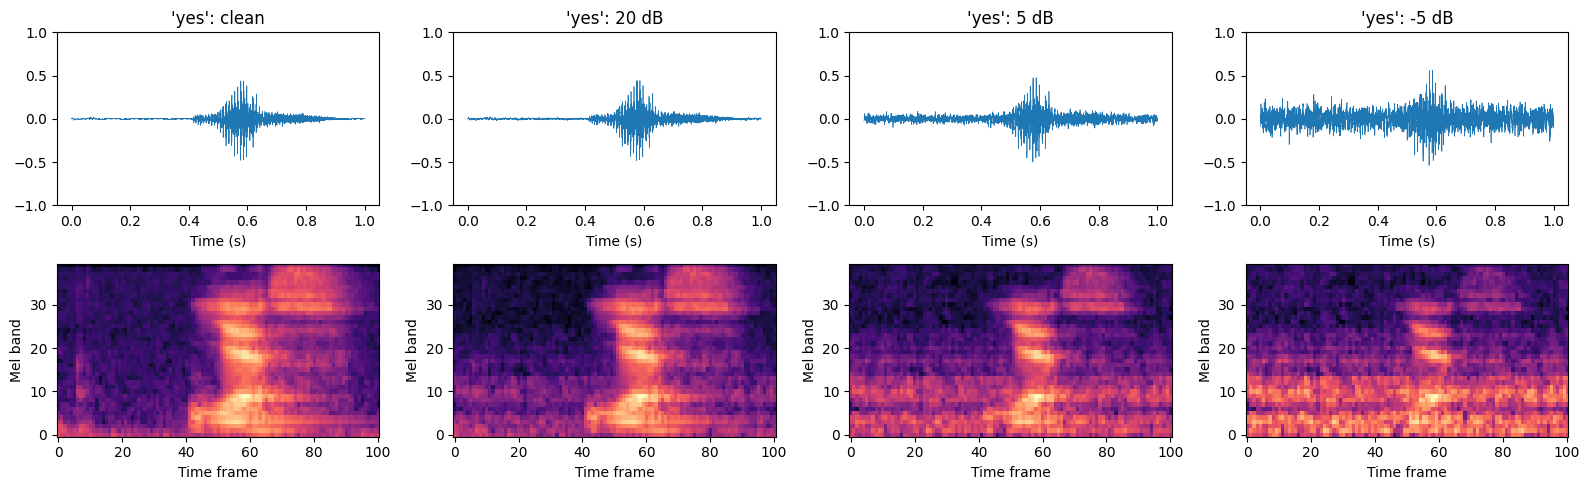

In [59]:
#12: Clean vs. noisy: same validation clip at several SNRs (validation noise only)
clip = load_audio(val_files[0])
noise = sample_noise_clip([val_noise_bank[0]], np.random.default_rng(SEED))  # doing_the_dishes
versions = [("clean", clip)] + [(f"{s} dB", mix_noise_at_snr(clip, noise, s)) for s in [20, 5, -5]]
with torch.inference_mode():
    specs = front_end(torch.from_numpy(np.stack([a for _, a in versions])).to(device)).cpu().numpy()

t = np.arange(NUM_SAMPLES) / SAMPLE_RATE
fig, axes = plt.subplots(2, len(versions), figsize=(16, 5), squeeze=False)
for i, (name, audio) in enumerate(versions):
    axes[0, i].plot(t, audio, lw=0.5)
    axes[0, i].set(title=f"'{LABELS[val_labels[0]]}': {name}", ylim=(-1, 1), xlabel="Time (s)")
    axes[1, i].imshow(specs[i, 0], origin="lower", aspect="auto", cmap="magma")
    axes[1, i].set(xlabel="Time frame", ylabel="Mel band")
plt.tight_layout()
plt.show()

In [60]:
#13: Model architectures BC-ResNet-1, DS-CNN
class SubSpectralNorm(nn.Module):
    def __init__(self, num_features, spec_groups=5):
        super().__init__()
        self.spec_groups = spec_groups
        self.bn = nn.BatchNorm2d(num_features * spec_groups)

    def forward(self, x):
        b, c, f, t = x.shape
        x = self.bn(x.reshape(b, c * self.spec_groups, f // self.spec_groups, t))
        return x.reshape(b, c, f, t)

class BCResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stage_idx, freq_stride):
        super().__init__()
        self.transition = in_ch != out_ch
        f2 = []
        if self.transition:
            f2 += [nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        f2 += [nn.Conv2d(out_ch, out_ch, (3, 1), (freq_stride, 1), (1, 0), groups=out_ch, bias=False),
               SubSpectralNorm(out_ch)]
        self.f2 = nn.Sequential(*f2)
        d = 2 ** stage_idx  # temporal dilation per stage: 1, 2, 4, 8
        self.f1 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, (1, 3), padding=(0, d), dilation=(1, d), groups=out_ch, bias=False),
            nn.BatchNorm2d(out_ch), nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 1, bias=False),
            nn.Dropout2d(0.1),
        )

    def forward(self, x):
        aux = self.f2(x)                                     # (B, C, F, T)
        out = self.f1(aux.mean(dim=2, keepdim=True)) + aux   # (B, C, 1, T) broadcast over F
        if not self.transition:
            out = out + x
        return torch.relu(out)

class BCResNet1(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        base_c = 8
        c = [base_c * 2, base_c, int(base_c * 1.5), base_c * 2, int(base_c * 2.5), base_c * 4]
        blocks_per_stage = [2, 2, 4, 4]
        stride_stages = (1, 2)  # first block of these stages halves the frequency axis
        self.head = nn.Sequential(nn.Conv2d(1, c[0], 5, (2, 1), 2, bias=False),
                                  nn.BatchNorm2d(c[0]), nn.ReLU(inplace=True))
        blocks = []
        for s, reps in enumerate(blocks_per_stage):
            for i in range(reps):
                freq_stride = 2 if (s in stride_stages and i == 0) else 1
                blocks.append(BCResBlock(c[s] if i == 0 else c[s + 1], c[s + 1], s, freq_stride))
        self.blocks = nn.Sequential(*blocks)
        self.classifier = nn.Sequential(
            nn.Conv2d(c[-2], c[-2], (5, 5), padding=(0, 2), groups=c[-2], bias=False),
            nn.Conv2d(c[-2], c[-1], 1, bias=False), nn.BatchNorm2d(c[-1]), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(c[-1], num_classes, 1),
        )

    def forward(self, x):   # x: (B, 1, 40, T)
        return self.classifier(self.blocks(self.head(x))).flatten(1)


class DSCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        ch = 64
        layers = [nn.Conv2d(1, ch, (4, 10), stride=2, padding=(1, 5), bias=False), 
                  nn.BatchNorm2d(ch), nn.ReLU(inplace=True)]
        for _ in range(4):   # depthwise 3x3 -> BN -> ReLU -> pointwise 1x1 -> BN -> ReLU
            layers += [nn.Conv2d(ch, ch, 3, padding=1, groups=ch, bias=False),
                       nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
                       nn.Conv2d(ch, ch, 1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True)]
        self.features = nn.Sequential(*layers, nn.AdaptiveAvgPool2d(1))
        self.classifier = nn.Linear(ch, num_classes)

    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def count_macs(model, input_shape):
    macs = []

    def hook(m, inp, out):
        if isinstance(m, nn.Conv2d):
            macs.append(out.numel() * (m.in_channels // m.groups) * m.kernel_size[0] * m.kernel_size[1])
        else:
            macs.append(m.in_features * m.out_features)

    handles = [m.register_forward_hook(hook) for m in model.modules()
               if isinstance(m, (nn.Conv2d, nn.Linear))]
    was_training = model.training
    model.eval()
    model(torch.zeros(input_shape, device=next(model.parameters()).device))
    model.train(was_training)
    for h in handles:
        h.remove()
    return sum(macs)

MODELS = {"BC-ResNet-1": BCResNet1, "DS-CNN": DSCNN}
feature_shape = (1, 1, front_end.n_mels, 1 + NUM_SAMPLES // front_end.hop_length)  # (1, 1, 40, 101)

rows = []
for name, model_cls in MODELS.items():
    model = model_cls(num_classes=len(LABELS)).to(device).eval()
    with torch.no_grad():
        assert model(torch.zeros(2, *feature_shape[1:], device=device)).shape == (2, len(LABELS))
    params = count_params(model)
    rows.append({"model": name, "params": params, "size_fp32(kb)": params * 4 / 1024,
                 "macs(m)": count_macs(model, feature_shape) / 1e6})
display(pd.DataFrame(rows).set_index("model").round(2))


,params,size_fp32(kb),macs(m)
model,,,
BC-ResNet-1,9166,35.80,2.48
DS-CNN,23050,90.04,21.67


In [61]:
#14: Training & Evaluation Functions
EPOCHS = 100
WARMUP_EPOCHS = 5
PEAK_LR = 0.1
WEIGHT_DECAY = 1e-3
SEEDS = [SEED, SEED + 1, SEED + 2]
CKPT_DIR = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)


@torch.no_grad()
def evaluate(model, front_end, loader):
    model.eval()
    correct = total = 0
    for wav, labels in loader:
        wav, labels = wav.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        correct += (model(front_end(wav)).argmax(dim=1) == labels).sum().item()
        total += len(labels)
    return 100.0 * correct / total


def lr_at(step, total_steps, warmup_steps):
    if step < warmup_steps:
        return PEAK_LR * step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)
    return 0.5 * PEAK_LR * (1 + np.cos(np.pi * progress))


def train_model(model, train_loader, val_loader, val_noisy_loader, front_end, spec_aug, epochs, ckpt_path):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.0, momentum=0.9, weight_decay=WEIGHT_DECAY)
    steps_per_epoch = len(train_loader)
    total_steps, warmup_steps = epochs * steps_per_epoch, WARMUP_EPOCHS * steps_per_epoch
    history, best_score, step = [], -1.0, 0

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train(); spec_aug.train()
        loss_sum = torch.zeros((), device=device)
        correct = torch.zeros((), dtype=torch.long, device=device)
        for wav, labels in train_loader:
            step += 1
            lr = lr_at(step, total_steps, warmup_steps)
            for group in optimizer.param_groups:
                group["lr"] = lr
            wav, labels = wav.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            with torch.no_grad():
                specs = spec_aug(front_end(wav))
            outputs = model(specs)
            loss = nn.functional.cross_entropy(outputs, labels)
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            loss_sum += loss.detach() * len(labels)
            correct += (outputs.argmax(dim=1) == labels).sum()

        n = len(train_loader.dataset)
        val_acc = evaluate(model, front_end, val_loader)
        val_noisy_acc = evaluate(model, front_end, val_noisy_loader)
        score = (val_acc + val_noisy_acc) / 2
        if score > best_score:
            best_score = score
            torch.save(model.state_dict(), ckpt_path)
        history.append({"epoch": epoch, "lr": lr, "train_loss": loss_sum.item() / n,
                        "train_acc": 100.0 * correct.item() / n, "val_acc": val_acc,
                        "val_noisy_acc": val_noisy_acc, "time_s": time.time() - t0})
        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            h = history[-1]
            print(f"Epoch {epoch:3d}/{epochs} | lr {lr:.4f} | loss {h['train_loss']:.4f} | "
                  f"train {h['train_acc']:.2f}% | val clean {val_acc:.2f}% | "
                  f"val noisy {val_noisy_acc:.2f}% | {h['time_s']:.0f}s/epoch")

    model.load_state_dict(torch.load(ckpt_path, map_location=device))  # keep the best checkpoint
    return pd.DataFrame(history)

In [62]:
#15: Train both models with the same recipe and seeds; finished runs are loaded, not retrained
results = []
for seed in SEEDS:
    for name, model_cls in MODELS.items():
        tag = f"{name.replace(' ', '_')}_seed{seed}_e{EPOCHS}"
        ckpt_path, hist_path = CKPT_DIR / f"{tag}.pt", CKPT_DIR / f"{tag}_history.csv"
        if ckpt_path.exists() and hist_path.exists():
            print(f"[skip] {tag}: already trained")
            history = pd.read_csv(hist_path)
        else:
            print(f"--- {tag} ---")
            torch.manual_seed(seed)
            model = model_cls(num_classes=len(LABELS)).to(device)
            train_loader = make_train_loader(seed)
            history = train_model(model, train_loader, val_loader, val_noisy_loader,
                                  front_end, spec_aug, EPOCHS, ckpt_path)
            history.to_csv(hist_path, index=False)
        best = history.loc[((history["val_acc"] + history["val_noisy_acc"]) / 2).idxmax()]
        results.append({"model": name, "seed": seed, "best_epoch": int(best["epoch"]),
                        "val_acc": best["val_acc"], "val_noisy_acc": best["val_noisy_acc"],
                        "train_min": history["time_s"].sum() / 60})

results_df = pd.DataFrame(results)
display(results_df.round(2))
display(results_df.groupby("model")[["val_acc", "val_noisy_acc", "train_min"]].agg(["mean", "std"]).round(2))


[skip] BC-ResNet-1_seed2026_e100: already trained
[skip] DS-CNN_seed2026_e100: already trained
[skip] BC-ResNet-1_seed2027_e100: already trained
[skip] DS-CNN_seed2027_e100: already trained
[skip] BC-ResNet-1_seed2028_e100: already trained
[skip] DS-CNN_seed2028_e100: already trained


,model,seed,best_epoch,val_acc,val_noisy_acc,train_min
0,BC-ResNet-1,2026,92,96.73,91.87,26.60
1,DS-CNN,2026,99,96.76,91.39,23.22
2,BC-ResNet-1,2027,100,96.81,92.30,29.69
3,DS-CNN,2027,99,96.62,91.63,20.99
4,BC-ResNet-1,2028,95,96.92,91.57,26.43
5,DS-CNN,2028,94,96.68,91.76,21.27


val_acc       val_noisy_acc       train_min      
               mean   std          mean   std      mean   std
model                                                        
BC-ResNet-1   96.82  0.09         91.92  0.37     27.58  1.84
DS-CNN        96.69  0.07         91.59  0.19     21.83  1.21

In [63]:
#16: Final test evaluation: clean test + noisy conditions for every trained checkpoint
# Load the best checkpoint of every run (no training here)
trained = {}
for seed in SEEDS:
    for name, model_cls in MODELS.items():
        tag = f"{name.replace(' ', '_')}_seed{seed}_e{EPOCHS}"
        model = model_cls(num_classes=len(LABELS)).to(device)
        model.load_state_dict(torch.load(CKPT_DIR / f"{tag}.pt", map_location=device))
        trained[(name, seed)] = model.eval()


@torch.no_grad()
def evaluate_many(models, loader):
    correct, total = dict.fromkeys(models, 0), 0
    for wav, labels in loader:
        wav, labels = wav.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        specs = front_end(wav)
        for key, model in models.items():
            correct[key] += (model(specs).argmax(dim=1) == labels).sum().item()
        total += len(labels)
    return {key: 100.0 * c / total for key, c in correct.items()}


t0 = time.time()
rows = []
conditions = [("clean", "none", np.nan, test_loader)] + list(iter_test_loaders())
for group, noise_name, snr_db, loader in conditions:
    for (name, seed), acc in evaluate_many(trained, loader).items():
        rows.append({"model": name, "seed": seed, "group": group,
                     "noise": noise_name, "snr_db": snr_db, "acc": acc})
test_df = pd.DataFrame(rows)
print(f"Evaluated {len(trained)} checkpoints x {len(conditions)} test conditions in {time.time() - t0:.0f}s")


Evaluated 6 checkpoints x 31 test conditions in 81s


Test accuracy (%), mean and std over seeds


group       clean         seen       unseen      
             mean   std   mean   std   mean   std
model                                            
BC-ResNet-1  97.3  0.20  91.98  0.11  90.11  1.14
DS-CNN       97.2  0.15  91.88  0.30  90.96  0.20

BC-ResNet-1 minus DS-CNN (percentage points), per seed


group,clean,seen,unseen
2026,0.15,0.13,0.28
2027,0.05,0.38,-1.77
2028,0.10,-0.21,-1.08
mean,0.10,0.10,-0.86
std,0.05,0.29,1.04


Mean test accuracy (%) per SNR (dB)


snr_db               20.0   10.0   5.0    0.0   -5.0 
model       group                                    
BC-ResNet-1 seen    96.80  95.67  94.10  90.75  82.58
            unseen  96.25  94.44  92.21  88.12  79.52
DS-CNN      seen    96.61  95.51  93.87  90.59  82.82
            unseen  96.07  94.76  92.98  89.61  81.39

Mean test accuracy (%) per noise type, averaged over SNRs and seeds


noise,doing_the_dishes,exercise_bike,pink_noise,white_noise,running_tap,dude_miaowing
model,,,,,,
BC-ResNet-1,90.13,90.72,94.23,92.85,90.53,89.69
DS-CNN,89.31,91.16,94.18,92.88,92.33,89.60


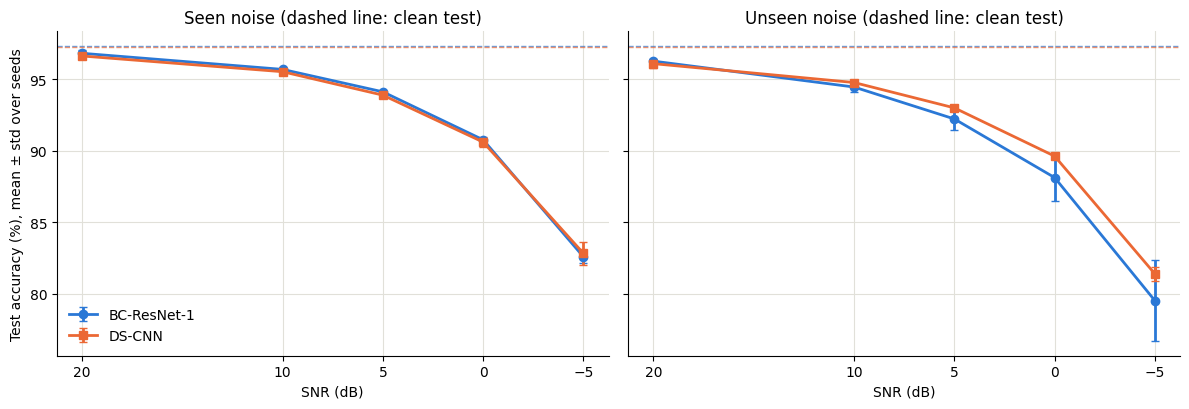

In [64]:
#17: Test results: summary, paired comparison, per-SNR and per-noise breakdown
# Per seed: clean accuracy and the mean over all seen / unseen noise conditions
per_seed = (test_df.groupby(["model", "seed", "group"])["acc"].mean()
            .unstack("group")[["clean", "seen", "unseen"]])
print("Test accuracy (%), mean and std over seeds")
display(per_seed.groupby("model").agg(["mean", "std"]).round(2))

# Paired by seed: both models of a seed saw the same data order and augmentation
model_a, model_b = MODELS
paired_diff = per_seed.loc[model_a] - per_seed.loc[model_b]
print(f"{model_a} minus {model_b} (percentage points), per seed")
display(pd.concat([paired_diff, paired_diff.agg(["mean", "std"])]).round(2))

# Average over noise types within each seed, then mean / std over seeds
noisy = test_df[test_df["group"] != "clean"]
by_snr = (noisy.groupby(["model", "seed", "group", "snr_db"])["acc"].mean()
          .groupby(["model", "group", "snr_db"]).agg(["mean", "std"]))
print("Mean test accuracy (%) per SNR (dB)")
display(by_snr["mean"].unstack("snr_db")[EVAL_SNRS].round(2))
print("Mean test accuracy (%) per noise type, averaged over SNRs and seeds")
display(noisy.groupby(["model", "noise"])["acc"].mean().unstack("noise")[test_noise_names].round(2))

SERIES_COLORS = {model_a: "#2a78d6", model_b: "#eb6834"}
SERIES_MARKERS = {model_a: "o", model_b: "s"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, group in zip(axes, ["seen", "unseen"]):
    for name in MODELS:
        d = by_snr.loc[(name, group)]
        ax.errorbar(d.index, d["mean"], yerr=d["std"], label=name, color=SERIES_COLORS[name],
                    marker=SERIES_MARKERS[name], markersize=6, linewidth=2, capsize=3)
        ax.axhline(per_seed.loc[name, "clean"].mean(), color=SERIES_COLORS[name],
                   linestyle="--", linewidth=1, alpha=0.7)
    ax.set(title=f"{group.capitalize()} noise (dashed line: clean test)", xlabel="SNR (dB)")
    ax.set_xticks(EVAL_SNRS)
    ax.invert_xaxis()  # harder conditions to the right
    ax.grid(color="#e1e0d9", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Test accuracy (%), mean ± std over seeds")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


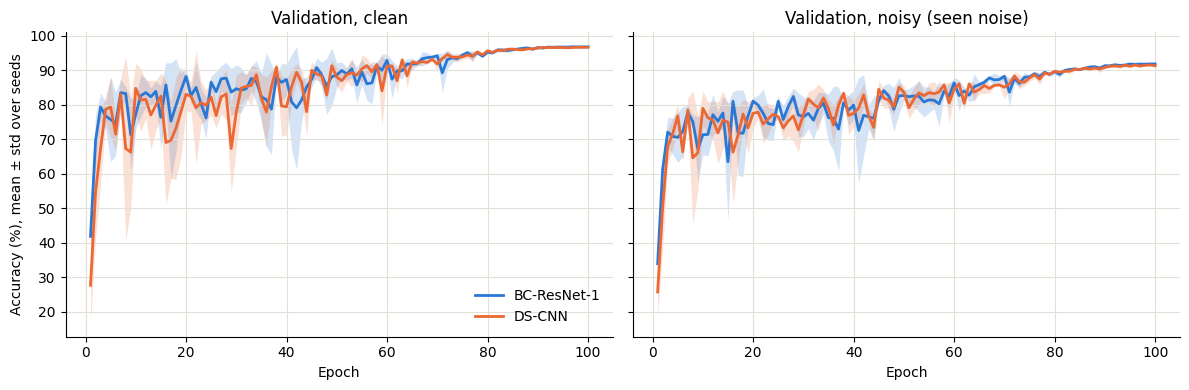

In [65]:
#18: Training curves: validation accuracy per epoch, mean ± std over seeds
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, title in zip(axes, ["val_acc", "val_noisy_acc"], ["Validation, clean", "Validation, noisy (seen noise)"]):
    for name in MODELS:
        runs = pd.concat([pd.read_csv(CKPT_DIR / f"{name.replace(' ', '_')}_seed{seed}_e{EPOCHS}_history.csv")
                          for seed in SEEDS])
        curve = runs.groupby("epoch")[col].agg(["mean", "std"])
        ax.plot(curve.index, curve["mean"], color=SERIES_COLORS[name], linewidth=2, label=name)
        ax.fill_between(curve.index, curve["mean"] - curve["std"], curve["mean"] + curve["std"],
                        color=SERIES_COLORS[name], alpha=0.2, linewidth=0)
    ax.set(title=title, xlabel="Epoch")
    ax.grid(color="#e1e0d9", linewidth=0.8)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Accuracy (%), mean ± std over seeds")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [66]:
#19: Inference cost on CPU (batch size = 1, one thread)
def latency_ms(fn, x, n_runs=300, n_warmup=30):
    with torch.inference_mode():
        for _ in range(n_warmup):
            fn(x)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            fn(x)
            times.append(time.perf_counter() - t0)
    return 1000 * np.median(times), 1000 * np.percentile(times, 90)

@torch.no_grad()
def largest_activation_kb(model, x):
    sizes = []
    handles = [m.register_forward_hook(lambda m, inp, out: sizes.append(out.numel()))
               for m in model.modules() if not list(m.children())]
    model(x)
    for h in handles:
        h.remove()
    return max(sizes) * 4 / 1024

prev_threads = torch.get_num_threads()
torch.set_num_threads(1)
cpu_front_end = AudioFrontEnd().eval()
wav = torch.from_numpy(load_audio(test_files[0])).unsqueeze(0)   # (1, 16000): one 1-second clip
with torch.no_grad():
    feats = cpu_front_end(wav)                                   # (1, 1, 40, 101)
fe_ms, fe_p90 = latency_ms(cpu_front_end, wav)
print(f"Front-end (log-Mel) on CPU: median {fe_ms:.2f} ms, p90 {fe_p90:.2f} ms (same for both models)")

rows = []
for name in MODELS:
    model = copy.deepcopy(trained[(name, SEEDS[0])]).cpu().eval()
    eager_ms, eager_p90 = latency_ms(model, feats)
    with torch.no_grad(), warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        scripted = torch.jit.optimize_for_inference(torch.jit.freeze(torch.jit.trace(model, feats)))
    script_ms, _ = latency_ms(scripted, feats)
    rows.append({"model": name, "macs(m)": count_macs(model, tuple(feats.shape)) / 1e6,
                 "largest_act(kb)": largest_activation_kb(model, feats),
                 "eager(ms)": eager_ms, "eager_p90(ms)": eager_p90, "torchscript(ms)": script_ms,
                 "end_to_end(ms)": fe_ms + eager_ms})
torch.set_num_threads(prev_threads)

latency_df = pd.DataFrame(rows).set_index("model")
display(latency_df.round(2))


Front-end (log-Mel) on CPU: median 0.33 ms, p90 0.45 ms (same for both models)


,macs(m),largest_act(kb),eager(ms),eager_p90(ms),torchscript(ms),end_to_end(ms)
model,,,,,,
BC-ResNet-1,2.48,126.25,3.91,4.60,3.80,4.24
DS-CNN,21.67,255.00,1.38,1.73,0.96,1.71


In [67]:
#20: Trade-off summary table: accuracy, noise robustness, size, memory, compute and speed
acc_mean = per_seed.groupby("model").mean()
acc_std = per_seed.groupby("model").std()

tradeoff_df = pd.DataFrame({"params": [count_params(trained[(n, SEEDS[0])]) for n in MODELS]},
                           index=list(MODELS))
tradeoff_df["size_fp32(kb)"] = tradeoff_df["params"] * 4 / 1024
tradeoff_df = tradeoff_df.join(latency_df[["macs(m)", "largest_act(kb)", "end_to_end(ms)"]])
for col in ["clean", "seen", "unseen"]:
    tradeoff_df[f"acc_{col}(%)"] = (acc_mean[col].map("{:.2f}".format) + " ± "
                                    + acc_std[col].map("{:.2f}".format))
display(tradeoff_df.round(2))

cost_cols = ["params", "macs(m)", "largest_act(kb)", "end_to_end(ms)"]
ratio = tradeoff_df.loc[model_b, cost_cols] / tradeoff_df.loc[model_a, cost_cols]
print(f"{model_b} / {model_a} cost ratio:", ratio.astype(float).round(2).to_dict())

,params,size_fp32(kb),macs(m),largest_act(kb),end_to_end(ms),acc_clean(%),acc_seen(%),acc_unseen(%)
BC-ResNet-1,9166,35.80,2.48,126.25,4.24,97.30 ± 0.20,91.98 ± 0.11,90.11 ± 1.14
DS-CNN,23050,90.04,21.67,255.00,1.71,97.20 ± 0.15,91.88 ± 0.30,90.96 ± 0.20


DS-CNN / BC-ResNet-1 cost ratio: {'params': 2.51, 'macs(m)': 8.73, 'largest_act(kb)': 2.02, 'end_to_end(ms)': 0.4}


In [68]:
#21: Ablation: the same recipe with SpecAugment enabled
ABLATION_SEEDS = SEEDS
spec_aug_on = SpecAugment().to(device)

for seed in ABLATION_SEEDS:
    for name, model_cls in MODELS.items():
        tag = f"{name.replace(' ', '_')}_seed{seed}_e{EPOCHS}_specaug"
        ckpt_path, hist_path = CKPT_DIR / f"{tag}.pt", CKPT_DIR / f"{tag}_history.csv"
        if ckpt_path.exists() and hist_path.exists():
            print(f"[skip] {tag}: already trained")
            continue
        print(f"--- {tag} ---")
        torch.manual_seed(seed)
        model = model_cls(num_classes=len(LABELS)).to(device)
        train_loader = make_train_loader(seed)
        history = train_model(model, train_loader, val_loader, val_noisy_loader,
                              front_end, spec_aug_on, EPOCHS, ckpt_path)
        history.to_csv(hist_path, index=False)

[skip] BC-ResNet-1_seed2026_e100_specaug: already trained
[skip] DS-CNN_seed2026_e100_specaug: already trained
[skip] BC-ResNet-1_seed2027_e100_specaug: already trained
[skip] DS-CNN_seed2027_e100_specaug: already trained
[skip] BC-ResNet-1_seed2028_e100_specaug: already trained
[skip] DS-CNN_seed2028_e100_specaug: already trained


In [69]:
#22: Ablation results: test accuracy with vs. without SpecAugment, paired by seed
ablation_models = {}
for seed in ABLATION_SEEDS:
    for name, model_cls in MODELS.items():
        tag = f"{name.replace(' ', '_')}_seed{seed}_e{EPOCHS}_specaug"
        model = model_cls(num_classes=len(LABELS)).to(device)
        model.load_state_dict(torch.load(CKPT_DIR / f"{tag}.pt", map_location=device))
        ablation_models[(name, seed)] = model.eval()

rows = []
for group, noise_name, snr_db, loader in [("clean", "none", np.nan, test_loader)] + list(iter_test_loaders()):
    for (name, seed), acc in evaluate_many(ablation_models, loader).items():
        rows.append({"model": name, "seed": seed, "group": group, "acc": acc})
ablation_per_seed = (pd.DataFrame(rows).groupby(["model", "seed", "group"])["acc"].mean()
                     .unstack("group")[["clean", "seen", "unseen"]])

# The same seeds without SpecAugment
baseline = per_seed[per_seed.index.get_level_values("seed").isin(ABLATION_SEEDS)]
comparison = pd.concat({"off": baseline, "on": ablation_per_seed}, names=["specaug"])
print("Test accuracy (%), mean and std over seeds")
display(comparison.groupby(["model", "specaug"]).agg(["mean", "std"]).round(2))

diff = ablation_per_seed - baseline  # aligned on (model, seed)
print("SpecAugment on minus off (percentage points), paired by seed")
display(diff.groupby("model").agg(["mean", "std"]).round(2))

Test accuracy (%), mean and std over seeds


group                clean         seen       unseen      
                      mean   std   mean   std   mean   std
model       specaug                                       
BC-ResNet-1 off      97.30  0.20  91.98  0.11  90.11  1.14
            on       97.05  0.09  91.60  0.28  89.23  0.87
DS-CNN      off      97.20  0.15  91.88  0.30  90.96  0.20
            on       97.41  0.38  91.94  0.27  89.94  0.85

SpecAugment on minus off (percentage points), paired by seed


group       clean        seen       unseen      
             mean   std  mean   std   mean   std
model                                           
BC-ResNet-1 -0.25  0.28 -0.38  0.38  -0.88  1.47
DS-CNN       0.20  0.39  0.06  0.11  -1.03  0.72

In [70]:
#23: Inference demo: BC-ResNet-1 (seed 2026) on six clean test clips
demo_front_end = AudioFrontEnd().to(device).eval()
demo_model = BCResNet1(num_classes=len(LABELS)).to(device)
demo_model.load_state_dict(torch.load(CKPT_DIR / f"BC-ResNet-1_seed{SEED}_e{EPOCHS}.pt", map_location=device))
demo_model.eval()


def predict_keyword(wav_path):
    wav = torch.from_numpy(load_audio(wav_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(demo_model(demo_front_end(wav)), dim=1)[0].cpu().numpy()
    k = int(np.argmax(probs))
    return LABELS[k], float(probs[k])

for path, label in zip(test_files[::800], test_labels[::800]):
    word, conf = predict_keyword(path)
    print(f"{Path(path).name:28s} true: {LABELS[label]:5s} | predicted: {word:5s} ({100 * conf:.1f}%)")


022cd682_nohash_0.wav        true: yes   | predicted: yes   (99.6%)
f0ae7203_nohash_0.wav        true: no    | predicted: no    (99.2%)
daf230ac_nohash_0.wav        true: down  | predicted: down  (100.0%)
d962e5ac_nohash_1.wav        true: right | predicted: right (99.8%)
d962e5ac_nohash_2.wav        true: off   | predicted: up    (88.9%)
d0faf7e4_nohash_3.wav        true: go    | predicted: no    (51.8%)


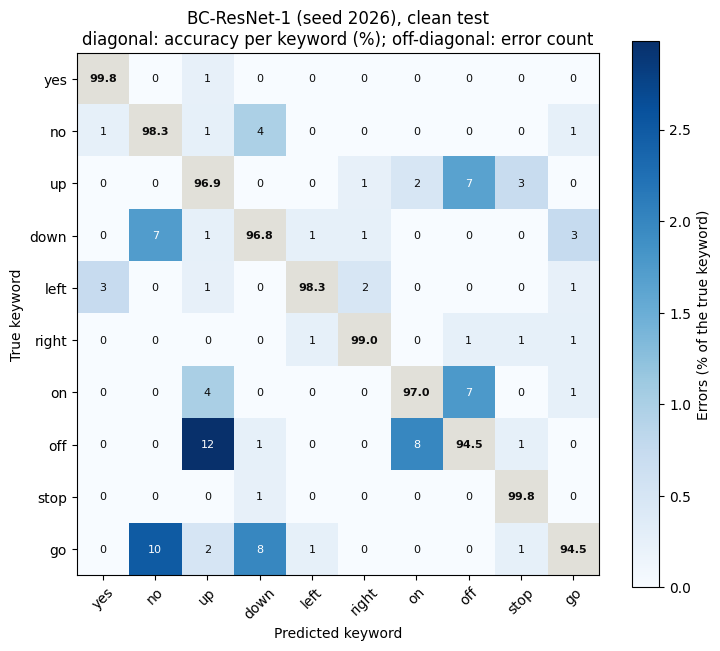

Most frequent confusions (count, true, predicted): [(12, 'off', 'up'), (10, 'go', 'no'), (8, 'off', 'on'), (8, 'go', 'down'), (7, 'up', 'off')]


In [71]:
#24: Confusion matrix of BC-ResNet-1 (seed 2026) on the clean test set (rows: true keyword, columns: predicted keyword)
with torch.no_grad():
    clean_preds = torch.cat([demo_model(front_end(wav.to(device))).argmax(dim=1).cpu() for wav, _ in test_loader])
clean_labels = torch.tensor(test_labels)
n = len(LABELS)
cm = torch.bincount(clean_labels * n + clean_preds, minlength=n * n).reshape(n, n)

counts = cm.numpy()
cm_pct = 100 * counts / counts.sum(axis=1, keepdims=True)
errors = np.where(np.eye(n, dtype=bool), np.nan, cm_pct)
fig, ax = plt.subplots(figsize=(7.5, 6.5))
ax.set_facecolor("#e1e0d9")
im = ax.imshow(errors, cmap="Blues", vmin=0)
for i in range(n):
    for j in range(n):
        if i == j:
            ax.text(j, i, f"{cm_pct[i, j]:.1f}", ha="center", va="center", fontsize=8, fontweight="bold", color="#0b0b0b")
        else:
            ax.text(j, i, str(counts[i, j]), ha="center", va="center", fontsize=8,
                    color="white" if errors[i, j] > np.nanmax(errors) / 2 else "#0b0b0b")
ax.set_xticks(range(n), LABELS, rotation=45)
ax.set_yticks(range(n), LABELS)
ax.set(xlabel="Predicted keyword", ylabel="True keyword",
       title="BC-ResNet-1 (seed 2026), clean test\ndiagonal: accuracy per keyword (%); off-diagonal: error count")
fig.colorbar(im, ax=ax, label="Errors (% of the true keyword)")
plt.tight_layout()
plt.show()

confusions = sorted(((int(cm[i, j]), LABELS[i], LABELS[j]) for i in range(n) for j in range(n) if i != j), reverse=True)
print("Most frequent confusions (count, true, predicted):", confusions[:5])

In [72]:
#25: Noisy inference demo: one test clip per keyword, 5 with seen and 5 with unseen test noise
demo_rng = np.random.default_rng(SEED)
seen_idx = [i for i, g in enumerate(test_noise_groups) if g == "seen"]
unseen_idx = [i for i, g in enumerate(test_noise_groups) if g == "unseen"]
label_array = np.array(test_labels)

for k, word in enumerate(LABELS):
    path = test_files[demo_rng.choice(np.flatnonzero(label_array == k))]
    noise_idx = int(demo_rng.choice(seen_idx if k % 2 == 0 else unseen_idx))  # alternate seen / unseen
    snr = float(demo_rng.choice(EVAL_SNRS))
    noisy = mix_noise_at_snr(load_audio(path), sample_noise_clip([test_noise_bank[noise_idx]], demo_rng), snr)
    with torch.no_grad():
        logits = demo_model(demo_front_end(torch.from_numpy(noisy).unsqueeze(0).to(device)))[0].cpu()
    probs = torch.softmax(logits, dim=0)
    pred = int(probs.argmax())
    print(f"{k + 1:2d}. true: {word:5s} | noise: {test_noise_names[noise_idx]} ({test_noise_groups[noise_idx]}, {snr:g} dB) "
          f"| predicted: {LABELS[pred]:5s} | confidence {100 * probs[pred].item():.1f}%")


 1. true: yes   | noise: doing_the_dishes (seen, 20 dB) | predicted: yes   | confidence 97.7%
 2. true: no    | noise: running_tap (unseen, 20 dB) | predicted: no    | confidence 99.9%
 3. true: up    | noise: exercise_bike (seen, -5 dB) | predicted: up    | confidence 97.6%
 4. true: down  | noise: dude_miaowing (unseen, 0 dB) | predicted: down  | confidence 99.9%
 5. true: left  | noise: pink_noise (seen, 20 dB) | predicted: left  | confidence 100.0%
 6. true: right | noise: dude_miaowing (unseen, 0 dB) | predicted: right | confidence 99.2%
 7. true: on    | noise: pink_noise (seen, 0 dB) | predicted: off   | confidence 96.5%
 8. true: off   | noise: dude_miaowing (unseen, 0 dB) | predicted: off   | confidence 99.4%
 9. true: stop  | noise: exercise_bike (seen, 5 dB) | predicted: stop  | confidence 91.0%
10. true: go    | noise: running_tap (unseen, 20 dB) | predicted: go    | confidence 99.6%


Recording in 3...
Recording in 2...
Recording in 1...
Speak now!
Recording finished.
In-memory WAV: 32,044 bytes
Noise: 'my_noise.wav' (8.0 s), same random 1-s window at every SNR
Predicted keyword (confidence) for every condition:


,BC-ResNet-1,DS-CNN
clean,yes (94.6%),yes (69.1%)
20 dB,yes (98.7%),yes (98.5%)
10 dB,yes (95.5%),yes (92.6%)
5 dB,yes (81.9%),yes (58.6%)
0 dB,yes (40.5%),off (51.5%)
-5 dB,left (13.5%),off (35.7%)



############################################################
# Condition: clean
############################################################
[clean] BC-ResNet-1: predicted 'yes' (confidence 94.6%)


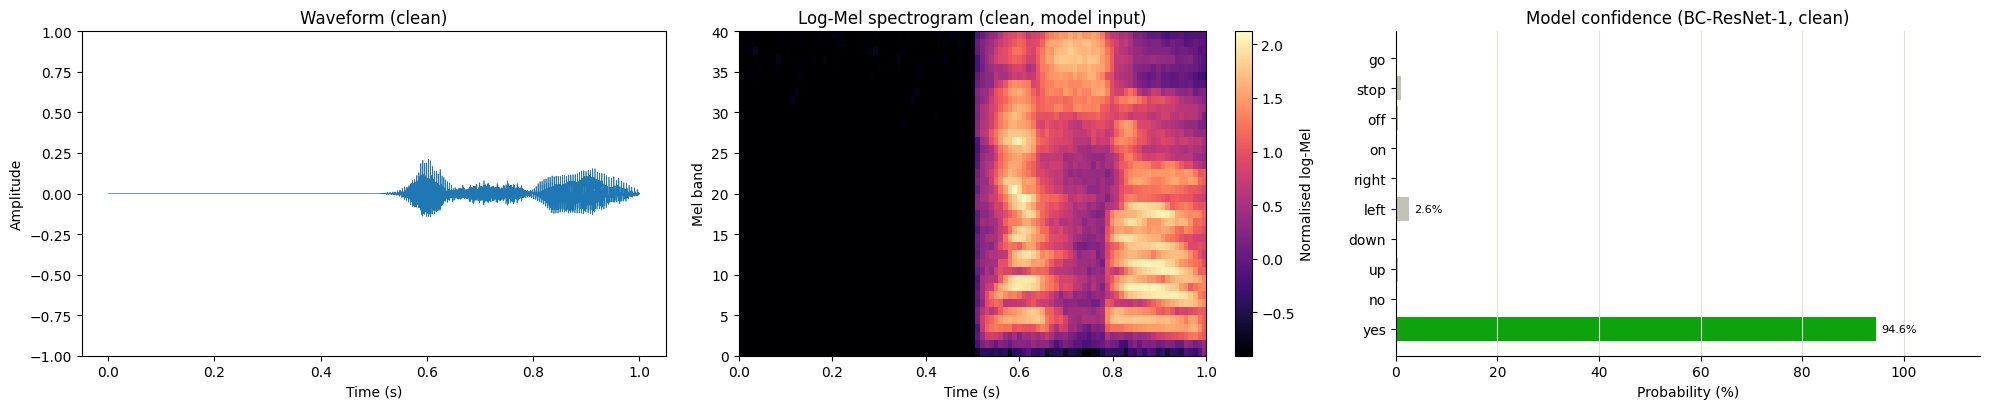

[clean] DS-CNN: predicted 'yes' (confidence 69.1%)


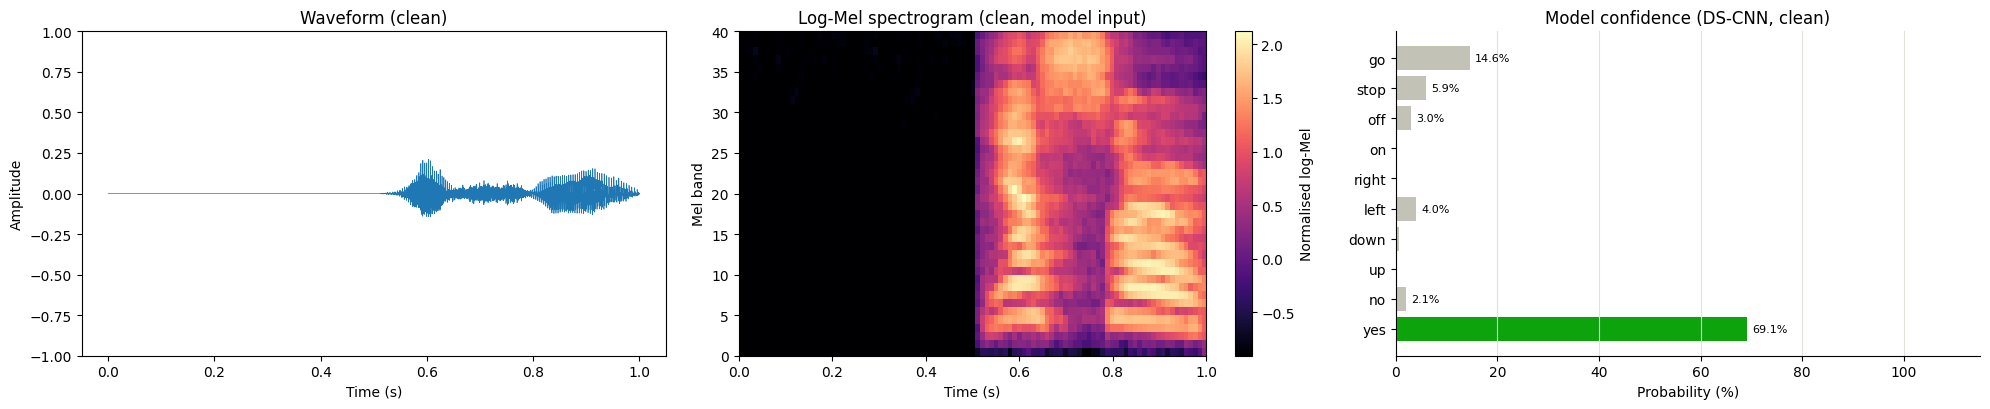


############################################################
# Condition: 20 dB
############################################################
[20 dB] BC-ResNet-1: predicted 'yes' (confidence 98.7%)


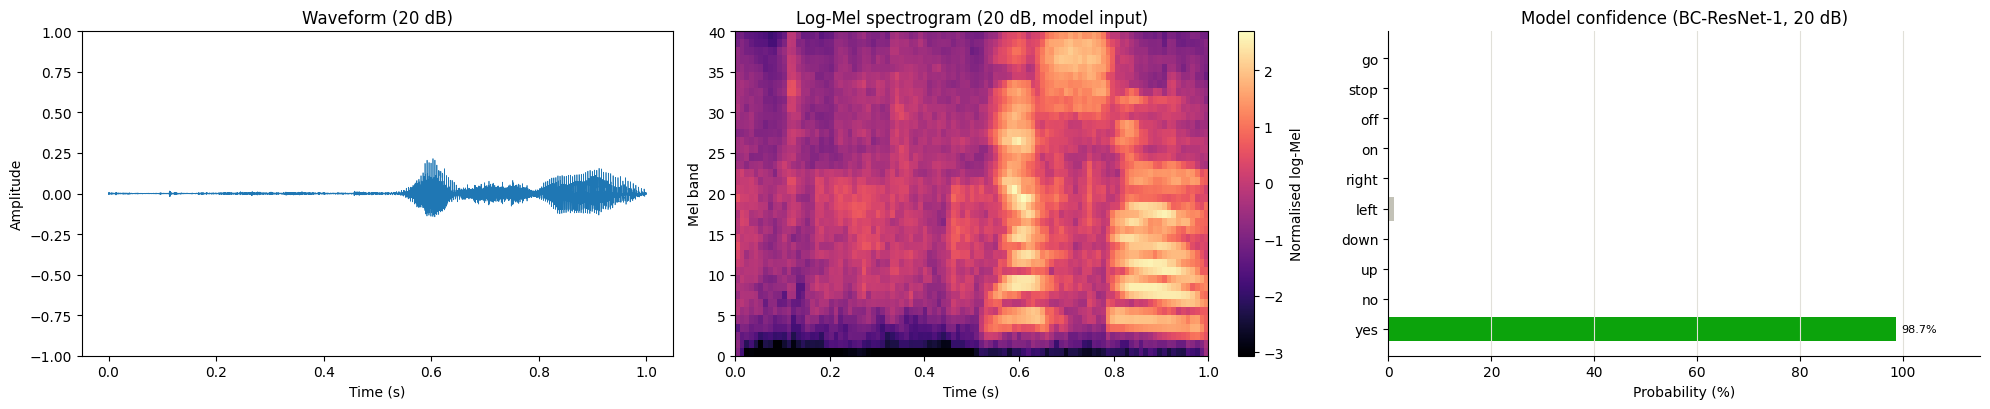

[20 dB] DS-CNN: predicted 'yes' (confidence 98.5%)


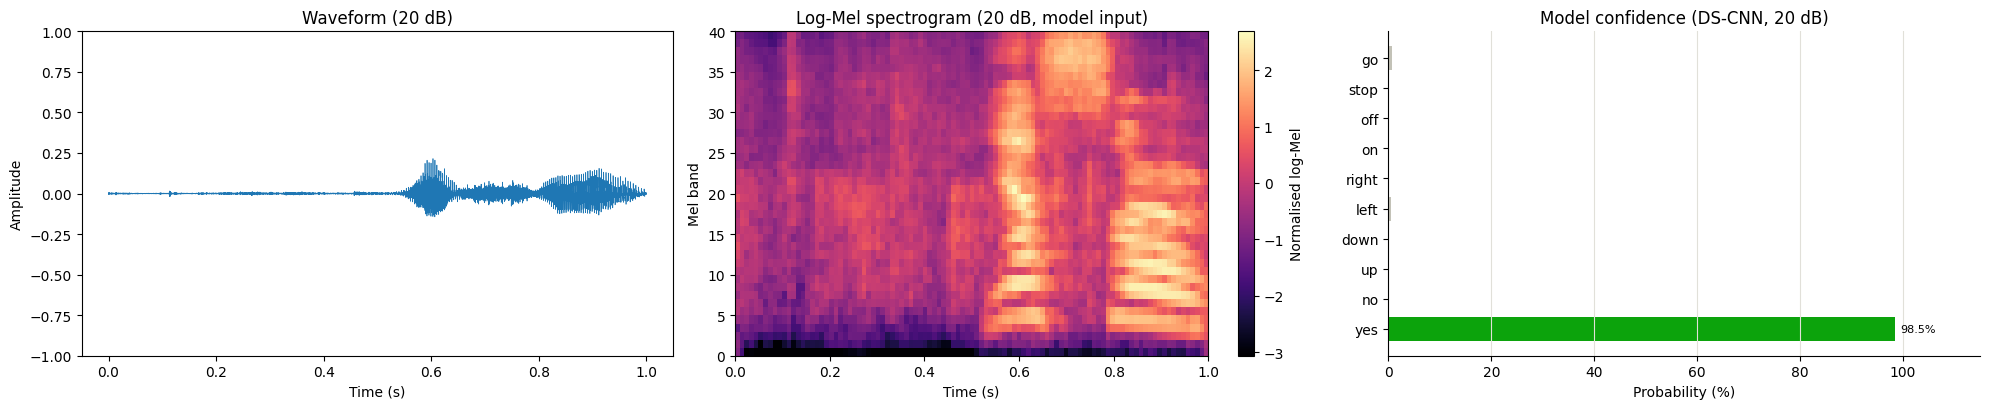


############################################################
# Condition: 10 dB
############################################################
[10 dB] BC-ResNet-1: predicted 'yes' (confidence 95.5%)


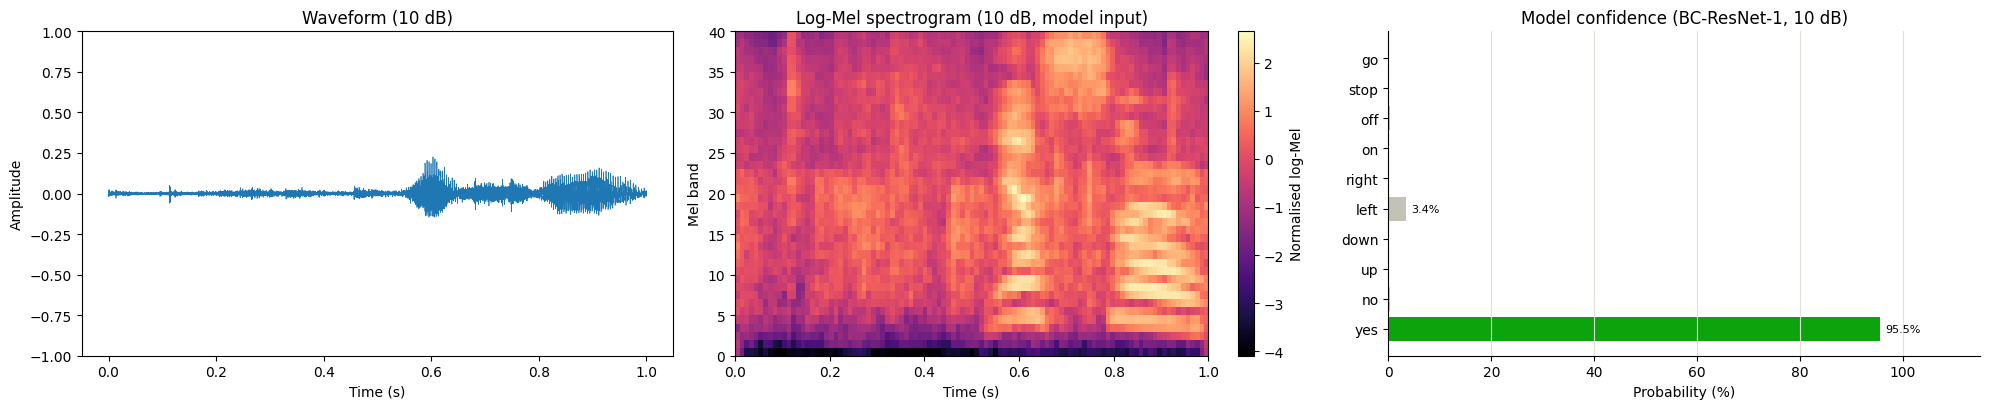

[10 dB] DS-CNN: predicted 'yes' (confidence 92.6%)


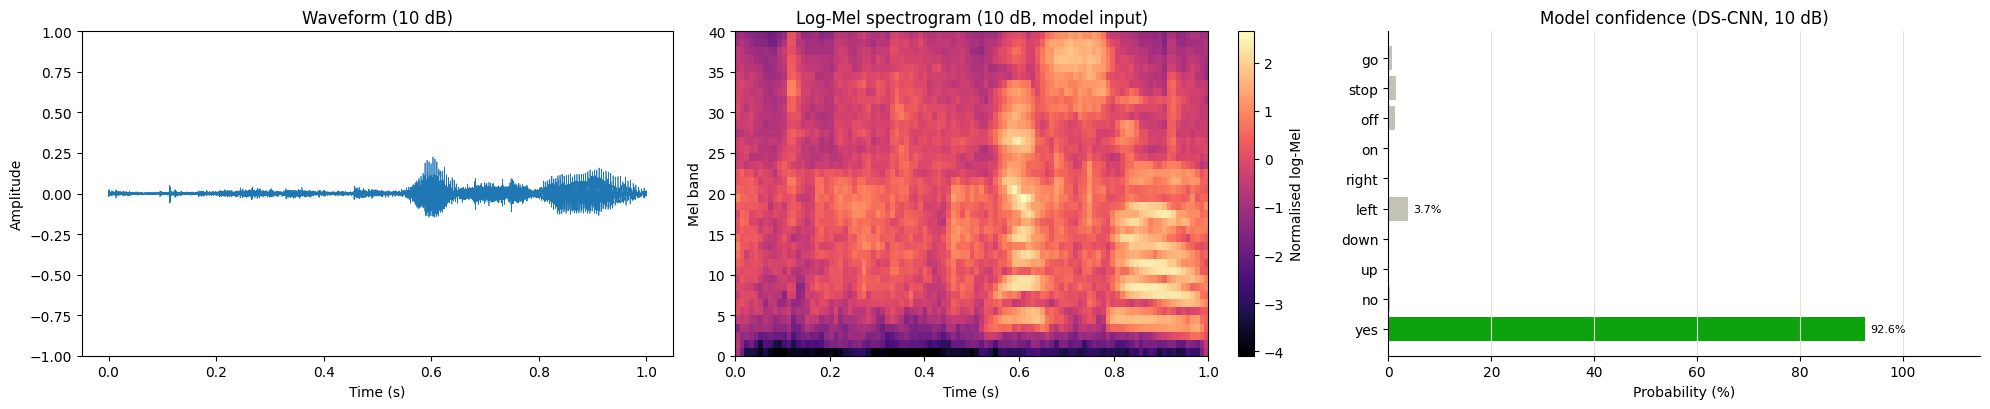


############################################################
# Condition: 5 dB
############################################################
[5 dB] BC-ResNet-1: predicted 'yes' (confidence 81.9%)


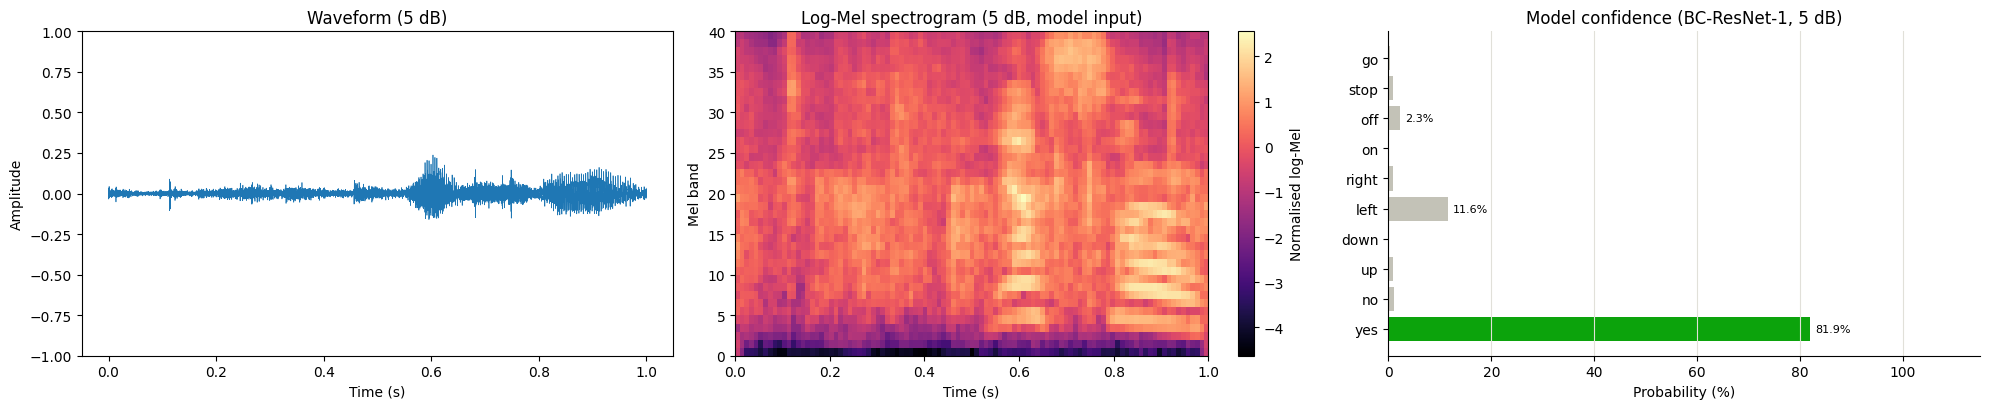

[5 dB] DS-CNN: predicted 'yes' (confidence 58.6%)


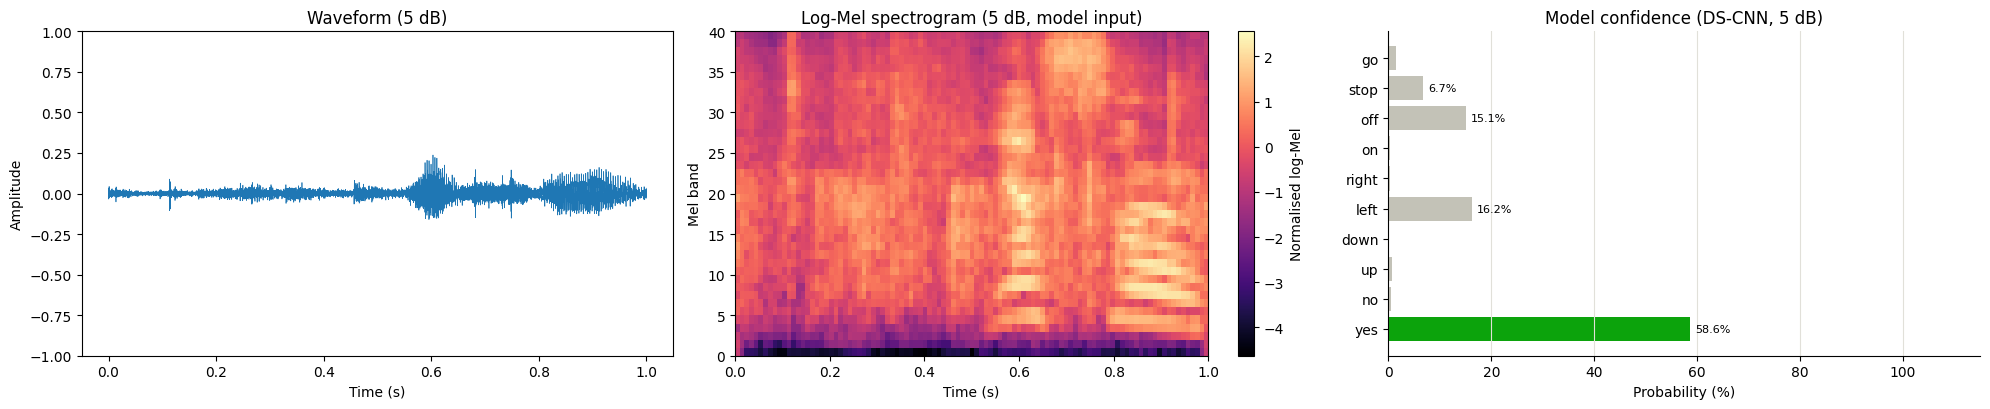


############################################################
# Condition: 0 dB
############################################################
[0 dB] BC-ResNet-1: predicted 'yes' (confidence 40.5%)


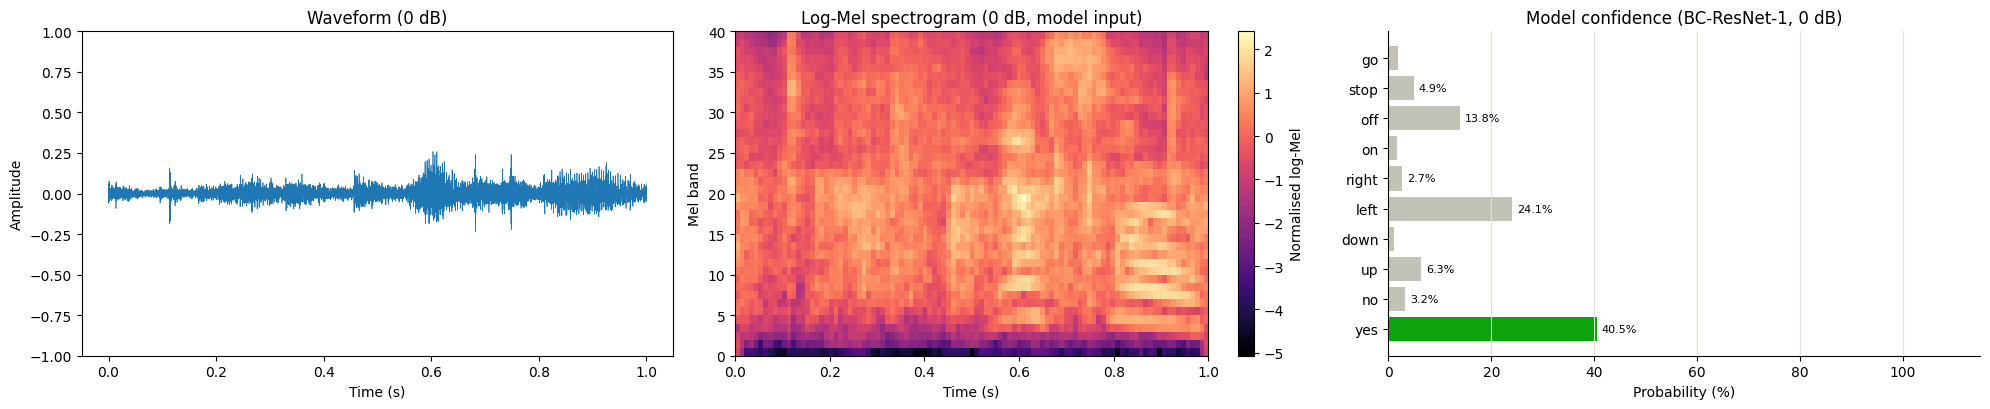

[0 dB] DS-CNN: predicted 'off' (confidence 51.5%)


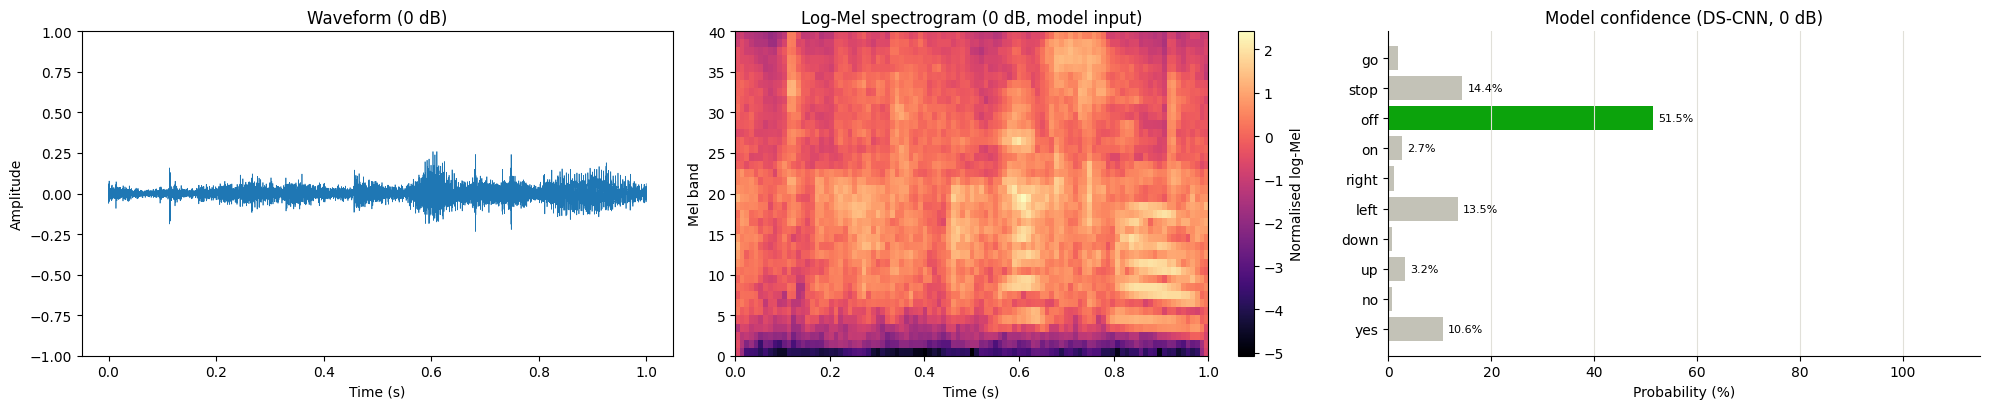


############################################################
# Condition: -5 dB
############################################################
[-5 dB] BC-ResNet-1: predicted 'left' (confidence 13.5%)


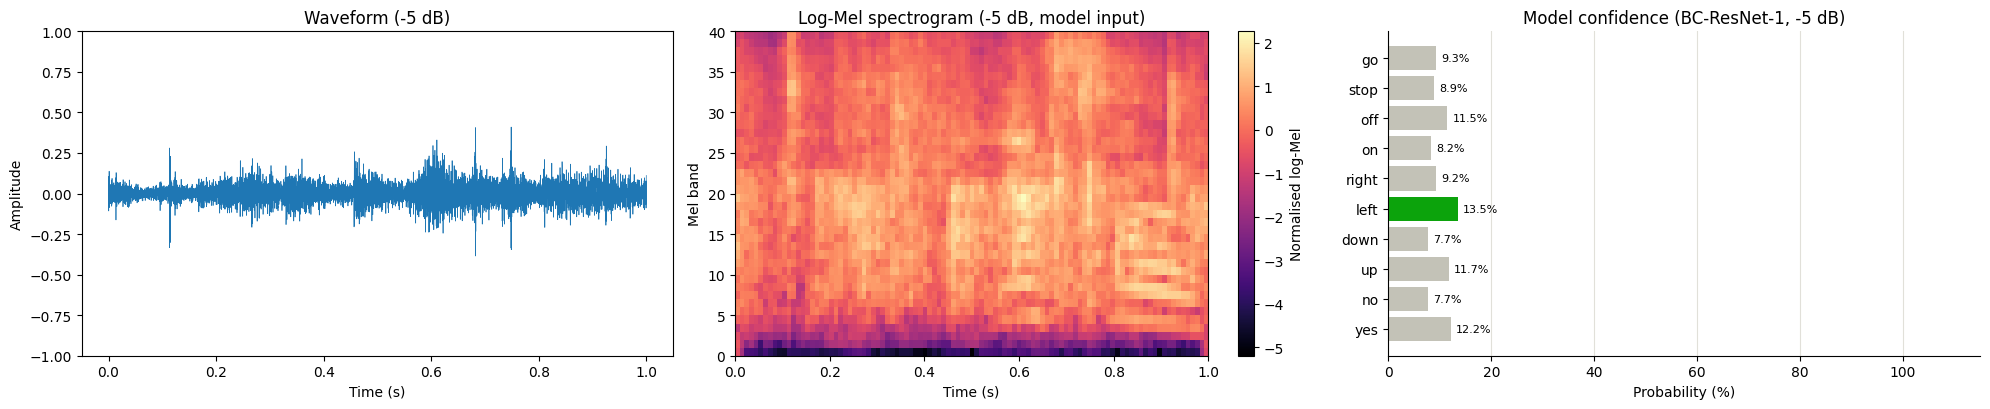

[-5 dB] DS-CNN: predicted 'off' (confidence 35.7%)


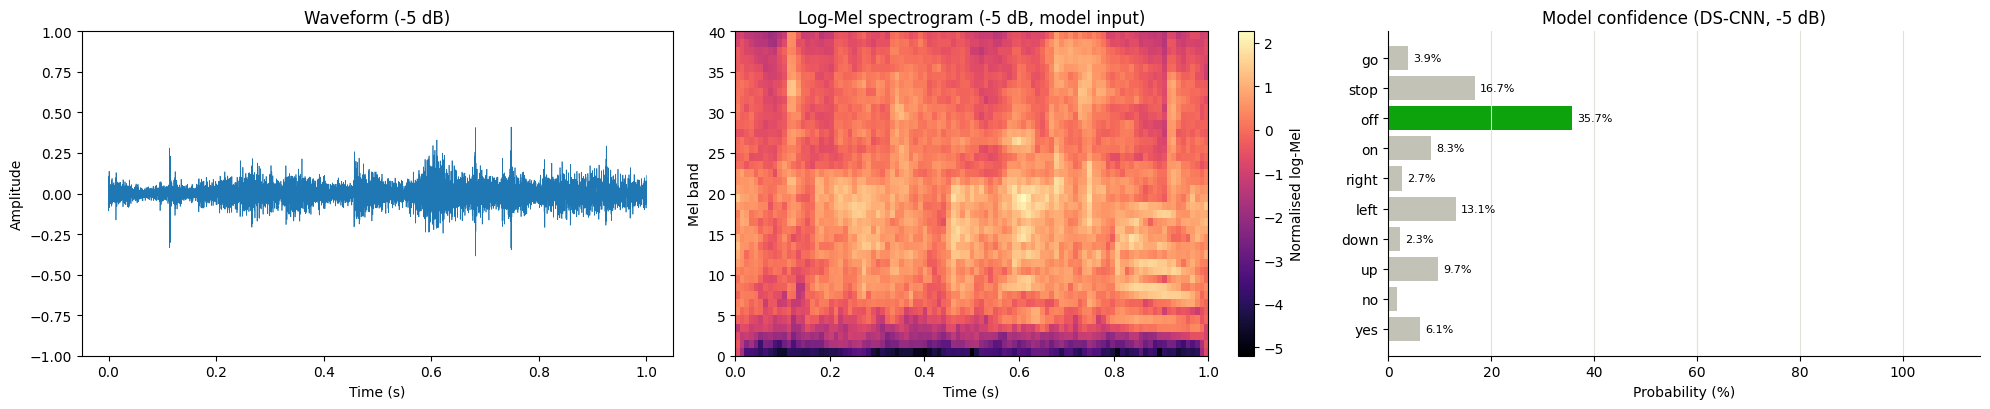

In [79]:
#26: Live microphone demo: record 1 s, mix my_noise.wav at every test SNR, predict with both models
NOISE_FILE = "my_noise.wav" 


def load_noise(path):
    sr, x = wavfile.read(path)
    if np.issubdtype(x.dtype, np.integer):
        x = x / (np.iinfo(x.dtype).max + 1.0)
    x = np.asarray(x, dtype=np.float32)
    if x.ndim == 2:
        x = x.mean(axis=1)
    if sr != SAMPLE_RATE:
        x = resample(torch.from_numpy(x), sr, SAMPLE_RATE).numpy()
    return x


def predict_both(x):
    with torch.no_grad():
        feats = demo_front_end(torch.from_numpy(x).unsqueeze(0).to(device))
        return feats, {name: 100 * torch.softmax(trained[(name, SEED)](feats), dim=1)[0].cpu().numpy()
                       for name in MODELS}


for s in (3, 2, 1):
    print(f"Recording in {s}...", flush=True)
    time.sleep(1)
print("Speak now!", flush=True)
pcm = sd.rec(NUM_SAMPLES, samplerate=SAMPLE_RATE, channels=1, dtype="int16")
sd.wait()
print("Recording finished.")

wav_buffer = io.BytesIO()
wavfile.write(wav_buffer, SAMPLE_RATE, pcm[:, 0])
wav_buffer.seek(0)
print(f"In-memory WAV: {len(wav_buffer.getvalue()):,} bytes")

clean = load_audio(wav_buffer)
cases = {"clean": clean}
if NOISE_FILE is not None:
    noise = load_noise(NOISE_FILE)
    noise_clip = sample_noise_clip([noise], np.random.default_rng(SEED))  # longer noise -> random 1-s window
    print(f"Noise: '{NOISE_FILE}' ({len(noise) / SAMPLE_RATE:.1f} s), same random 1-s window at every SNR")
    for snr in EVAL_SNRS:
        cases[f"{snr} dB"] = mix_noise_at_snr(clean, noise_clip, snr)

results = {}
for case, x in cases.items():
    _, pct = predict_both(x)
    results[case] = {name: f"{LABELS[int(np.argmax(p))]} ({p.max():.1f}%)" for name, p in pct.items()}
print("Predicted keyword (confidence) for every condition:")
display(pd.DataFrame.from_dict(results, orient="index"))

for case, audio in cases.items():
    features, pct = predict_both(audio)
    spec = features[0, 0].cpu().numpy()
    print("\n" + "#" * 60 + f"\n# Condition: {case}\n" + "#" * 60)
    for i, name in enumerate(MODELS):
        p = pct[name]
        k = int(np.argmax(p))
        print("=" * 60)
        print(f"[{case}] {name}: predicted '{LABELS[k]}' (confidence {p[k]:.1f}%)")
        print("=" * 60, flush=True)
        if i == 0:
            display(Audio(audio, rate=SAMPLE_RATE, normalize=False)) 

        fig, axes = plt.subplots(1, 3, figsize=(20, 4.2))
        axes[0].plot(np.arange(NUM_SAMPLES) / SAMPLE_RATE, audio, lw=0.5)
        axes[0].set(title=f"Waveform ({case})", xlabel="Time (s)", ylabel="Amplitude", ylim=(-1, 1))
        im = axes[1].imshow(spec, origin="lower", aspect="auto", cmap="magma", extent=[0, 1, 0, spec.shape[0]])
        axes[1].set(title=f"Log-Mel spectrogram ({case}, model input)", xlabel="Time (s)", ylabel="Mel band")
        fig.colorbar(im, ax=axes[1], label="Normalised log-Mel")
        colors = ["#c3c2b7"] * len(LABELS)
        colors[k] = "#0ca30c"
        axes[2].barh(LABELS, p, color=colors)
        for y, pi in enumerate(p):
            if pi >= 2:
                axes[2].text(pi + 1, y, f"{pi:.1f}%", va="center", fontsize=8)
        axes[2].set(title=f"Model confidence ({name}, {case})", xlabel="Probability (%)", xlim=(0, 115))
        axes[2].grid(axis="x", color="#e1e0d9", linewidth=0.8)
        axes[2].spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()